# Geopolitics Terrarium — 解析ノートブック

コミット済み実行ログ（`server/logs/`）のみから、提出レポートの根拠を再現する:

1. **実行ログの棚卸し** — 何が・どのseedで・どういう条件下で走ったか
2. **因果カスケード** — 神の介入1件が何件のイベント連鎖を生んだか（イベントのparentリンクをBFSで追跡）
3. **介入点×指標の感度** — どの介入点がどの指標に効くか
4. **A/B反実仮想** — 同seedでの介入あり/なしの世界GDP系列
5. **RL戦術層の学習曲線** — 単一国家学習と自己対戦学習
6. **LLM戦略層の思考ログ** — 国家AIが残した判断の理由（生ログ）

シミュレーションを再実行せずログから再現する点自体が、本作品の**再現性設計**
（イベントソーシング＋決定論エンジン）のデモンストレーションになっている。

In [1]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

ROOT = Path.cwd().parent if Path.cwd().name == "analysis" else Path.cwd()
LOGS = ROOT / "server" / "logs"
MODELS = ROOT / "server" / "models"
OUT = ROOT / "analysis" / "out"
plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.3})
print("committed runs:", sorted(p.name for p in LOGS.iterdir() if p.is_dir()))

committed runs: ['ab_earth_financial_crisis_earth', 'earth_baseline', 'earth_earth_bailout_or_contagion', 'earth_earth_ban_fusion', 'earth_earth_financial_crisis', 'earth_earth_hormuz', 'earth_earth_taiwan', 'earth_earth_triple_crisis', 'earth_financial_crisis_rl_debtors', 'earth_financial_crisis_rl_debtors_dd', 'earth_llm_hormuz']


## 1. 実行ログの棚卸し

In [2]:
rows = []
for d in sorted(LOGS.iterdir()):
    rj = d / "run.json"
    if not rj.exists():
        continue
    m = json.loads(rj.read_text())
    fm = m["final_metrics"]
    rows.append({
        "run": d.name, "seed": m["seed"], "ticks": m["ticks"],
        "final_gdp": fm["world_gdp"], "defaults": fm["defaults"],
        "wars": fm["wars"], "price_energy": fm["price_energy"],
        "price_chips": fm["price_chips"],
        "shortages": m.get("event_counts", {}).get("shortage", 0),
    })
df_runs = pd.DataFrame(rows).set_index("run")
df_runs.round(2)

,seed,ticks,final_gdp,defaults,wars,price_energy,price_chips,shortages
run,,,,,,,,
earth_baseline,42,36,189.20,1,0,1.00,1.00,312
earth_earth_bailout_or_contagion,42,36,130.66,3,0,1.26,1.08,464
earth_earth_ban_fusion,42,36,154.47,2,0,1.34,1.08,403
earth_earth_financial_crisis,42,36,129.48,4,0,1.26,1.08,463
earth_earth_hormuz,42,36,154.22,2,0,1.22,1.09,457
earth_earth_taiwan,42,36,166.68,2,0,1.01,1.04,390
earth_earth_triple_crisis,42,36,132.89,2,0,1.26,1.09,572
earth_financial_crisis_rl_debtors,42,36,127.75,5,0,1.21,1.08,457
earth_financial_crisis_rl_debtors_dd,42,36,127.75,5,0,1.21,1.08,457


## 2. 因果カスケード: 介入1件が生む連鎖

`events.jsonl` の各イベントは原因イベントのID列（`parents`）を持つ。
神の介入・技術創発を根として子孫を辿り、**どの介入がどれほどの連鎖を生んだか**を数える。

In [3]:
def load_events(run):
    evs = [json.loads(l) for l in (LOGS / run / "events.jsonl").read_text().splitlines() if l.strip()]
    return {e["id"]: e for e in evs}


def descendant_ids(events, root_id):
    children = {}
    for e in events.values():
        for p in e["parents"]:
            children.setdefault(p, []).append(e["id"])
    seen, stack = set(), [root_id]
    while stack:
        for c in children.get(stack.pop(), ()):
            if c not in seen:
                seen.add(c)
                stack.append(c)
    return seen


def cascade_table(run):
    events = load_events(run)
    roots = [e for e in events.values() if e["type"] in ("god_intervention", "tech_emergence")]
    rows = []
    for e in roots:
        desc = descendant_ids(events, e["id"])
        kinds = {}
        for d in desc:
            kinds[events[d]["type"]] = kinds.get(events[d]["type"], 0) + 1
        top = ", ".join(f"{k}x{v}" for k, v in sorted(kinds.items(), key=lambda x: -x[1])[:4])
        rows.append({"tick": e["tick"], "root_type": e["type"], "root": e["text"][:40],
                     "descendants": len(desc), "top_effects": top})
    return pd.DataFrame(rows).sort_values("descendants", ascending=False)


cascade_table("earth_earth_financial_crisis").head(8)

,tick,root_type,root,descendants,top_effects
1,6,god_intervention,神が海峡 Strait of Hormuz を封鎖した,470,"shortagex237, trade_throttledx233"
0,5,tech_emergence,研究フロンティア突破: 「サイバー攻撃基盤」が論文から原型へ（LLM生成の攻撃ツ,14,tech_adoptedx14
6,14,tech_emergence,研究フロンティア突破: 「高出力レーザー迎撃」が論文から原型へ（艦載指向エネルギ,14,tech_adoptedx14
7,15,tech_emergence,研究フロンティア突破: 「AI神格宗教の広がり」が論文から原型へ（LLMを神格と,14,tech_adoptedx14
8,16,tech_emergence,研究フロンティア突破: 「バイオ製造プラント」が論文から原型へ（発酵タンクでタン,13,tech_adoptedx13
2,8,tech_emergence,研究フロンティア突破: 「自律ドローン群」が論文から原型へ（群制御論文から生まれ,12,tech_adoptedx12
9,18,tech_emergence,研究フロンティア突破: 「テクノ・ナショナリズム」が論文から原型へ（技術主権を国,12,tech_adoptedx12
11,22,tech_emergence,研究フロンティア突破: 「極超音速迎撃網」が論文から原型へ（極超音速弾道の迎撃ア,12,tech_adoptedx12


### デフォルト連鎖（債務不履行の感染チェーン）

親イベントの型を見ると、**封鎖→輸入インフレ→金利上昇**で起きたデフォルトと、
**他国デフォルトのcredibility_hitから感染**したデフォルトが区別できる。

In [4]:
events = load_events("earth_earth_financial_crisis")
rows = []
for e in sorted((e for e in events.values() if e["type"] == "sovereign_default"),
                key=lambda x: x["tick"]):
    rows.append({
        "tick": e["tick"], "nation": e["actor"],
        "rate%": round(e["data"]["rate"] * 100, 1),
        "debt_gdp": e["data"]["debt_gdp"],
        "parents": [events[p]["type"] for p in e["parents"]],
    })
pd.DataFrame(rows)

,tick,nation,rate%,debt_gdp,parents
0,7,JPN,10.3,132.1,[]
1,12,EUR,19.2,50.2,[]
2,20,JPN,23.7,91.9,[]
3,22,USA,13.1,76.9,[]


## 3. 介入点×指標の感度行列

各シナリオの最終指標とbaselineの差分（`analysis/out/sensitivity_matrix.csv`）。
**同じseed・同じ世界**での差なので、差分は介入そのものに帰着できる。

In [5]:
sens = pd.read_csv(OUT / "sensitivity_matrix.csv", index_col=0)
sens.round(2)

,world_gdp,mean_stability,price_energy,price_chips,mean_debt_gdp,defaults,shortages
scenario,,,,,,,
earth_earth_bailout_or_contagion,-58.54,-1.38,0.26,0.08,1.5,2.0,152
earth_earth_ban_fusion,-34.73,-2.73,0.34,0.08,-4.0,1.0,91
earth_earth_financial_crisis,-59.72,-1.41,0.26,0.08,4.6,3.0,151
earth_earth_hormuz,-34.98,-0.53,0.22,0.09,-3.4,1.0,145
earth_earth_taiwan,-22.53,-0.38,0.01,0.04,-5.4,1.0,78
earth_earth_triple_crisis,-56.31,-2.20,0.26,0.09,-1.7,1.0,260
earth_financial_crisis_rl_debtors,-61.46,-1.62,0.21,0.08,0.1,4.0,145
earth_financial_crisis_rl_debtors_dd,-61.46,-1.79,0.21,0.08,0.1,4.0,145


/Users/kojiro/Documents/GitHub/kjranyone/meta-security-hackathon-vol-2/server/.venv/lib/python3.13/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 20171 (\N{CJK UNIFIED IDEOGRAPH-4ECB}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/kojiro/Documents/GitHub/kjranyone/meta-security-hackathon-vol-2/server/.venv/lib/python3.13/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 20837 (\N{CJK UNIFIED IDEOGRAPH-5165}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/kojiro/Documents/GitHub/kjranyone/meta-security-hackathon-vol-2/server/.venv/lib/python3.13/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 28857 (\N{CJK UNIFIED IDEOGRAPH-70B9}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/kojiro/Documents/GitHub/kjranyone/meta-security-hackathon-vol-2/server/.venv/lib/python3.13/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph

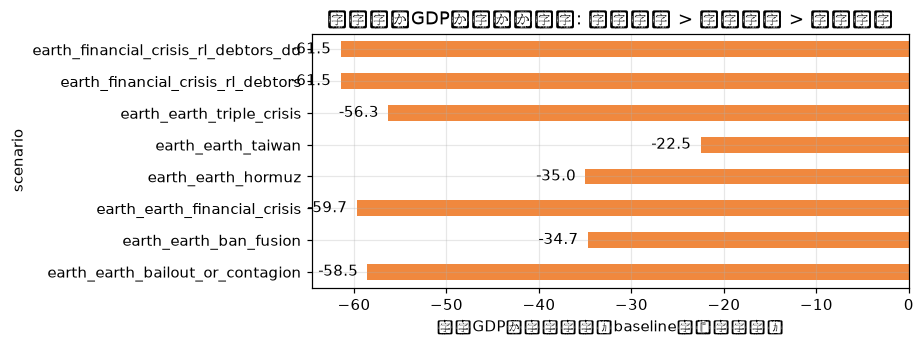

In [6]:
ax = sens["world_gdp"].plot.barh(figsize=(7, 3), color="#f0883e")
ax.set_xlabel("世界GDPの最終差分（baseline比、指数値）")
ax.set_title("介入点がGDPに与える打撃: 金融感染 > 三重封鎖 > 単独封鎖")
for i, v in enumerate(sens["world_gdp"]):
    ax.text(v - 1, i, f"{v:+.1f}", va="center", ha="right")
plt.show()

## 4. A/B反実仮想: 世界GDP系列

同一seed=42・同一地球プリセットで、介入だけを変えた場合の分岐。

/Users/kojiro/Documents/GitHub/kjranyone/meta-security-hackathon-vol-2/server/.venv/lib/python3.13/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 31070 (\N{CJK UNIFIED IDEOGRAPH-795E}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/kojiro/Documents/GitHub/kjranyone/meta-security-hackathon-vol-2/server/.venv/lib/python3.13/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 12424 (\N{HIRAGANA LETTER YO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/kojiro/Documents/GitHub/kjranyone/meta-security-hackathon-vol-2/server/.venv/lib/python3.13/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 27508 (\N{CJK UNIFIED IDEOGRAPH-6B74}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/kojiro/Documents/GitHub/kjranyone/meta-security-hackathon-vol-2/server/.venv/lib/python3.13/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 21490 (

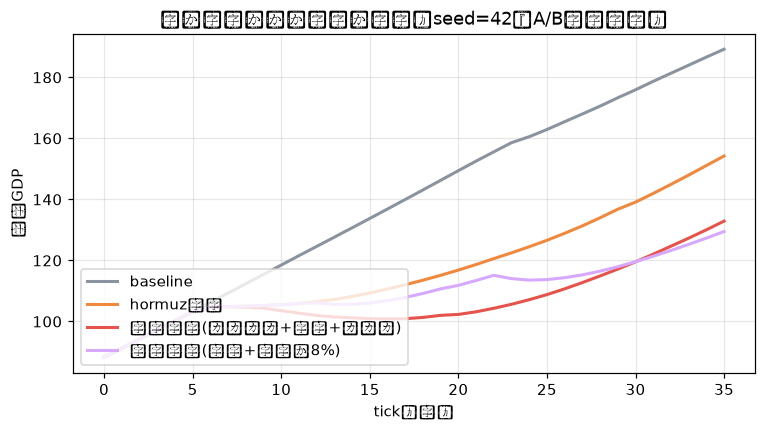

In [7]:
fig, ax = plt.subplots(figsize=(8, 4))
series = {
    "baseline": ("earth_baseline", "#8b949e"),
    "hormuz封鎖": ("earth_earth_hormuz", "#f0883e"),
    "三重危機(ホルムズ+台湾+スエズ)": ("earth_earth_triple_crisis", "#e5534b"),
    "金融危機(封鎖+利上げ8%)": ("earth_earth_financial_crisis", "#d6a8ff"),
}
for label, (run, color) in series.items():
    s = pd.read_csv(LOGS / run / "series.csv")
    ax.plot(s["tick"], s["world_gdp"], label=label, color=color, lw=2)
ax.set_xlabel("tick（月）"), ax.set_ylabel("世界GDP")
ax.legend(loc="lower left")
ax.set_title("神の介入による歴史の分岐（seed=42、A/B反実仮想）")
plt.show()

## 5. RL戦術層の学習曲線

単一国家学習（heuristic相手）と自己対戦学習（他の学習者も環境の一部）の
評価報酬推移。`models/*.curve.json` から読み込み。

/Users/kojiro/Documents/GitHub/kjranyone/meta-security-hackathon-vol-2/server/.venv/lib/python3.13/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 35413 (\N{CJK UNIFIED IDEOGRAPH-8A55}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/kojiro/Documents/GitHub/kjranyone/meta-security-hackathon-vol-2/server/.venv/lib/python3.13/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 20385 (\N{CJK UNIFIED IDEOGRAPH-4FA1}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/kojiro/Documents/GitHub/kjranyone/meta-security-hackathon-vol-2/server/.venv/lib/python3.13/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 22577 (\N{CJK UNIFIED IDEOGRAPH-5831}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/kojiro/Documents/GitHub/kjranyone/meta-security-hackathon-vol-2/server/.venv/lib/python3.13/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph

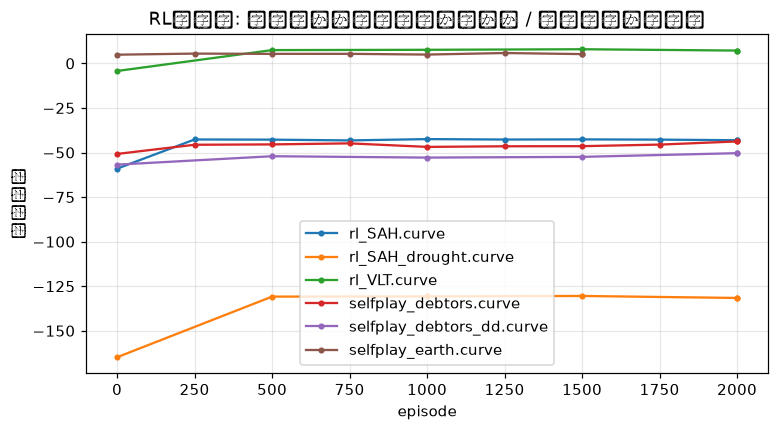

In [8]:
fig, ax = plt.subplots(figsize=(8, 4))
for f in sorted(MODELS.glob("*.curve.json")):
    c = json.loads(f.read_text())
    xs = [p["episode"] for p in c]
    if "eval_reward" in c[0]:
        ys = [p["eval_reward"] for p in c]
    else:  # self-play: per-nation eval -> mean
        ys = [sum(p["eval"].values()) / len(p["eval"]) for p in c]
    ax.plot(xs, ys, label=f.stem, marker=".")
ax.set_xlabel("episode"), ax.set_ylabel("評価報酬")
ax.legend()
ax.set_title("RL戦術層: 脆弱国ほど学習利得が大きい / 自己対戦は共進化")
plt.show()

## 6. LLM戦略層の思考ログ

`--policy llm`（z.ai GLM）実行の `policy_shift` イベントには、国家AIが
残した判断の理由（rationale）がそのまま記録されている。

In [9]:
llm_runs = [p for p in sorted(LOGS.iterdir())
            if (p / "run.json").exists() and "llm" in p.name]
if not llm_runs:
    print("LLM実行ログ未コミット（earth_llm_hormuz 完了後に再実行）")
for d in llm_runs:
    evs = [json.loads(l) for l in (d / "events.jsonl").read_text().splitlines() if l.strip()]
    rationales = [e for e in evs
                  if e["type"] == "policy_shift" and len(e["text"]) > 55
                  and "doctrine:" not in e["text"]]
    print(f"\n### {d.name} — LLM rationale {len(rationales)} 件")
    for e in sorted(rationales, key=lambda x: -len(x["text"]))[:6]:
        body = e["text"].split(":", 1)[-1].strip()
        print(f"  t{e['tick']:>2} {e['actor']}: {body[:150]}")


### earth_llm_hormuz — LLM rationale 33 件
  t 9 RUS: Energy shortage in Turkey and food shortage in Taiwan are opportunities. Expand dependencies through resource diplomacy.
  t10 SAU: 食料・チップ・鉱物の備蓄枯渇が存亡的危機。中国とブラジルから調達、エネルギー余剰をトルコに売り関係強化。内政優先の防衛態勢。
  t12 CAN: 食料・エネルギー輸出の cards 切り替え——TWN食料不足とKOR半導体を互恵貿易で結び、チップ備蓄ゼロの脆弱性を同盟で解消
  t 2 SAU: 食料備蓄仅2.17为致命弱点，最优先囤粮。以能源筹码换巴西粮食通商，维系对华能源纽带，改善对美关系以遏制动荡的伊朗
  t 5 BRA: 世界的食料不足は好機。食料備蓄を外交カードに中立的輸出拡大、TWN(半導体)・SAU(エネルギー)と相互補完関係を構築する。
  t 4 SAU: 食料備蓄2.3が存亡的脆弱点。配給継続で消費抑制し、ブラジル食料貿易と米中両建てで輸入路確保、防衛態勢


## まとめ: 介入点と連鎖の対応

| 介入点 | 観測された連鎖 | 副作用 |
|---|---|---|
| 海峡封鎖（ホルムズ） | エネルギー価格+50% → ファブ電力不足 → 半導体+31% → GDP -26.5% | 債務国の金利上昇 |
| 利上げ（世界金利+8%） | 債務国の利払い急増 → デフォルト → 債権国へcredibility_hit感染 | GDPへの打撃は三重封鎖超 |
| ベイルアウト | デフォルト計4件→3件 | GDP回復は限定的（モラルハザードの均衡） |
| 技術禁止（核融合ban） | 未来技術による海峡ショック吸収が消失 → エネルギー1.35 | 技術格差の固定化 |

詳細な図表は `analysis/out/`（生成スクリプト `analysis/make_figures.py`）。